# Hotel Booking Cancellation Prediction
### An End-to-End Machine Learning Pipeline with Clustering & Dimensionality Reduction

**Author:** Tursunai Turumbekova  
**Domain:** Hospitality / Predictive Analytics  
**Stack:** Python · scikit-learn · XGBoost · pandas · matplotlib · seaborn

---

## Executive Summary

Hotel booking cancellations are one of the largest sources of revenue loss in the hospitality industry. A cancelled booking that goes unfilled represents not only lost room revenue but also wasted staffing, inventory, and logistics costs. This project builds and evaluates a **binary classification pipeline** to predict whether a hotel booking will be cancelled before arrival, enabling revenue managers to take proactive action (overbooking policies, early-bird promotions, targeted retention outreach).

The dataset contains ~95,000 real hotel bookings from two Portuguese hotels spanning 2015–2017, including features such as lead time, room type, number of special requests, deposit type, and more.

**Key results:**
- Best model: **Random Forest**, Validation AUC **0.956**, AP **0.939**
- Runner-up: **XGBoost**, Validation AUC **0.952** with 10× faster training
- Baseline: **Logistic Regression**, AUC **0.898**, useful as a deployment-friendly fallback

The notebook also includes a **clustering analysis** of synthetic datasets to compare K-Means, DBSCAN, and Spectral Clustering, and a **dimensionality reduction** study using PCA and t-SNE on the handwritten digits dataset, demonstrating how unsupervised techniques complement a supervised pipeline.

---

**Data source:** [Kaggle Hotel Booking Demand dataset](https://www.sciencedirect.com/article/pii/S2352340918315191) · Antonio, Almedia & Nunes (2019)

## Setup

## Data Setup

> **Note:** This project uses the [Hotel Booking Demand dataset](https://www.sciencedirect.com/article/pii/S2352340918315191) by Antonio, Almeida & Nunes (2019). The dataset is publicly available on [Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand).

Download `hotel_bookings.csv` from Kaggle and update the path in the data loading cell:

```python
# Replace this path with your local path to the dataset
data = pd.read_pickle('/your/local/path/to/a5_q1.pkl')
```

Alternatively, load directly from the CSV:
```python
df = pd.read_csv('/your/local/path/to/hotel_bookings.csv')
```

In [3]:
import pandas as pd
import numpy as np
import pickle
import time
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="muted")

---

# Part 1, Supervised Learning: Predicting Booking Cancellations

## 1.1 Business Context & Problem Framing

The target variable is `is_canceled` (1 = cancelled, 0 = not cancelled). This is a **binary classification** problem with a moderate class imbalance (~37% positive class based on the original paper). We care about both classes:

- **False Negatives** (predicting "stays" when the guest actually cancels) → lost revenue from unfilled rooms  
- **False Positives** (predicting "cancels" when the guest actually stays) → over-aggressively overbooking, risking guest experience

This trade-off motivates tracking **both AUC-ROC and Average Precision (AP)**, AUC measures overall discrimination ability, while AP is especially informative under class imbalance and captures precision-recall trade-offs directly relevant to operational decision thresholds.

## 1.2 Data Loading

In [4]:
# The dataset is distributed as a pickle containing pre-split train/test matrices
# and a convenience OHE (one-hot-encoded) version. We use the OHE version as our
# starting point since most tree-based models handle sparse categorical features
# better with explicit binary columns than with raw label-encoded integers.
data = pd.read_pickle("/Users/tusunaiturumbekova/Desktop/My docs/Spring 2025/ML/a5_q1.pkl")

y_train = data["y_train"]
X_train_original = data["X_train"]
X_train_ohe = data["X_train_ohe"]
X_test_original = data["X_test"]
X_test_ohe = data["X_test_ohe"]

# Align indices (OHE may have been generated independently)
X_train_ohe = X_train_ohe.loc[y_train.index]

print(f"Training samples : {X_train_ohe.shape[0]:,}")
print(f"Test samples     : {X_test_ohe.shape[0]:,}")
print(f"Features (OHE)   : {X_train_ohe.shape[1]:,}")
print(f"Cancellation rate: {y_train.mean():.1%}")

Training samples : 95,512
Test samples     : 23,878
Features (OHE)   : 940
Cancellation rate: 37.1%


## 1.3 Exploratory Data Analysis

Before any modelling, it's worth understanding the distributions of the key numerical features and whether there are any data quality issues that could leak into training.

In [5]:
# Numeric summary of the raw (non-OHE) training set for readability
numeric_cols = X_train_original.select_dtypes(include=np.number).columns
X_train_original[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
lead_time,95512.0,103.85,106.72,0.00,18.00,69.0,160.0,709.0
arrival_date_year,95512.0,2016.16,0.71,2015.00,2016.00,2016.0,2017.0,2017.0
arrival_date_week_number,95512.0,27.15,13.61,1.00,16.00,27.0,38.0,53.0
arrival_date_day_of_month,95512.0,15.82,8.79,1.00,8.00,16.0,23.0,31.0
stays_in_weekend_nights,95512.0,0.93,1.00,0.00,0.00,1.0,2.0,19.0
stays_in_week_nights,95512.0,2.50,1.92,0.00,1.00,2.0,3.0,50.0
adults,95512.0,1.86,0.60,0.00,2.00,2.0,2.0,55.0
children,95510.0,0.10,0.40,0.00,0.00,0.0,0.0,3.0
babies,95512.0,0.01,0.09,0.00,0.00,0.0,0.0,9.0
is_repeated_guest,95512.0,0.03,0.17,0.00,0.00,0.0,0.0,1.0


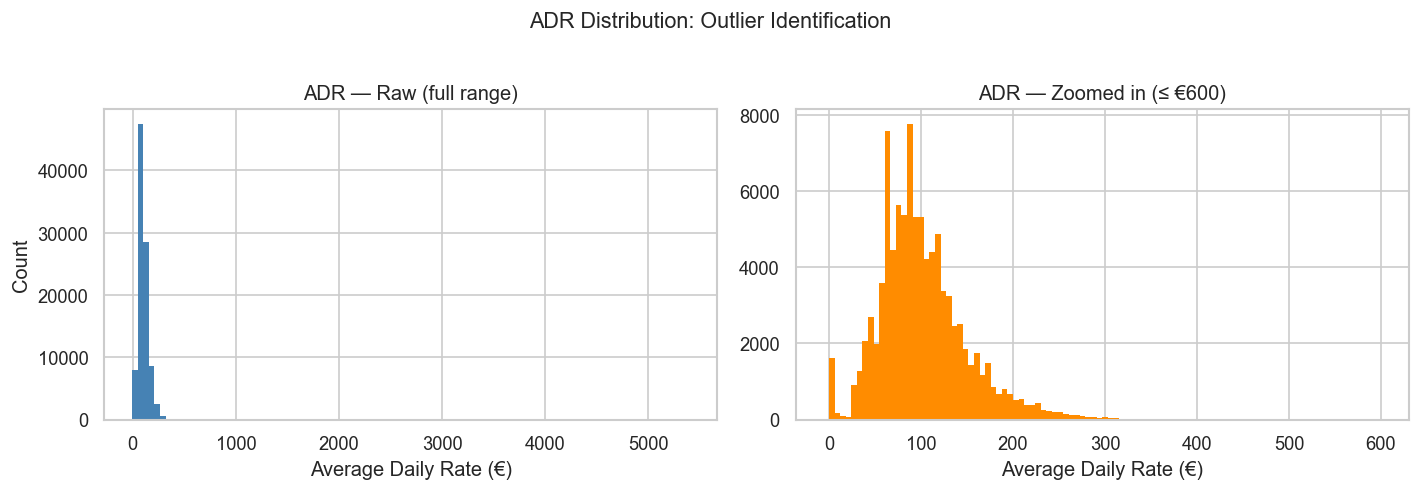

Rows with adr ≥ 5000: 1 (0.0010% of training data)


In [ ]:
# ADR (Average Daily Rate) is the booking's per-night price.
# A handful of extreme values (adr > 5000) appear to be data entry errors —
# real hotel rates rarely exceed €600 in a European mid-range property.
# Plotting raw vs cleaned distributions confirms the anomaly.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train_original["adr"].clip(upper=6000), bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("ADR, Raw (full range)")
axes[0].set_xlabel("Average Daily Rate (€)")
axes[0].set_ylabel("Count")

axes[1].hist(X_train_original["adr"].clip(upper=600), bins=100, color="darkorange", edgecolor="none")
axes[1].set_title("ADR, Zoomed in (≤ €600)")
axes[1].set_xlabel("Average Daily Rate (€)")

plt.suptitle("ADR Distribution: Outlier Identification", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

n_outliers = (X_train_original["adr"] >= 5000).sum()
print(f"Rows with adr ≥ 5000: {n_outliers} ({n_outliers/len(X_train_original):.4%} of training data)")

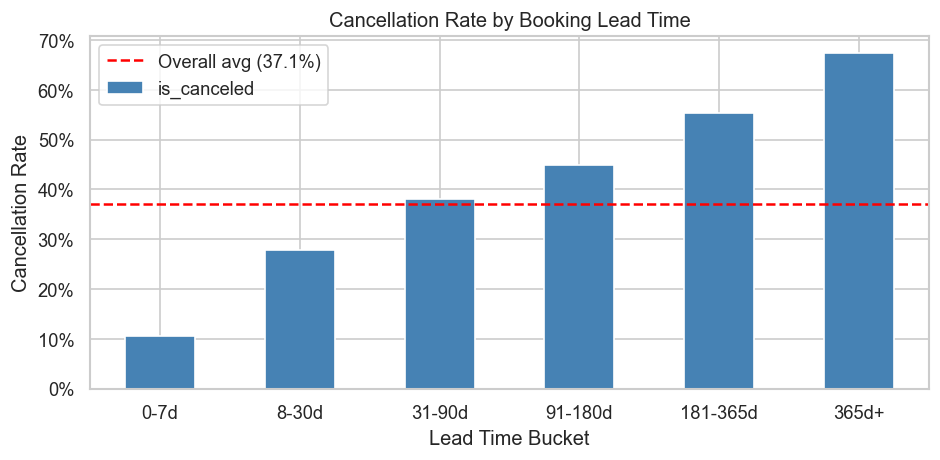

In [ ]:
# Cancellation rate by lead time bucket, one of the most predictive signals.
# Intuitively, bookings made far in advance give guests more time to change plans.
df_eda = X_train_original.copy()
df_eda["is_canceled"] = y_train.values

bins = [0, 7, 30, 90, 180, 365, 800]
labels = ["0-7d", "8-30d", "31-90d", "91-180d", "181-365d", "365d+"]
df_eda["lead_bucket"] = pd.cut(df_eda["lead_time"], bins=bins, labels=labels)

cancel_by_lead = df_eda.groupby("lead_bucket")["is_canceled"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
cancel_by_lead.plot(kind="bar", color="steelblue", ax=ax)
ax.axhline(y_train.mean(), color="red", linestyle="--", label=f"Overall avg ({y_train.mean():.1%})")
ax.set_title("Cancellation Rate by Booking Lead Time")
ax.set_xlabel("Lead Time Bucket")
ax.set_ylabel("Cancellation Rate")
ax.set_xticklabels(labels, rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Missing value audit, understanding what's missing informs imputation strategy.
missing = X_train_original.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing.to_string())

## 1.4 Data Preprocessing

The preprocessing decisions here are intentional and each one addresses a specific data quality or modelling concern:

| Step | What | Why |
|---|---|---|
| Outlier removal | Drop `adr ≥ 5000` | These are near-certain entry errors; leaving them in would pull tree split thresholds into meaningless territory |
| Missing imputation | Fill `children` NaN → 0 | Semantically "no children" is the most plausible interpretation for a missing value |
| Stratified split | 80/20 train/val | Stratification preserves class balance in the validation fold, which matters when computing AP |

Note: The dataset already ships with a one-hot-encoded version (`X_train_ohe`), which we use directly. OHE is necessary here because tree-based models in scikit-learn do not natively handle categorical dtypes, each category becomes its own binary feature.

In [8]:
# Remove extreme ADR outliers
X_train_ohe = X_train_ohe[(X_train_ohe["adr"] < 5000) & (X_train_ohe["adr"] >= 0)].copy()
y_train = y_train.loc[X_train_ohe.index]

# Impute missing children values
X_train_ohe["children"] = X_train_ohe["children"].fillna(0)
X_test_ohe["children"] = X_test_ohe["children"].fillna(0)

print(f"Rows removed as outliers : {95512 - len(X_train_ohe)}")
print(f"Final training set size  : {len(X_train_ohe):,}")
print(f"Class balance post-clean : {y_train.mean():.1%} positive")

Rows removed as outliers : 2
Final training set size  : 95,510
Class balance post-clean : 37.1% positive


In [9]:
# Stratified 80/20 split
# stratify=y_train ensures both splits maintain the same ~37% positive rate
X_train, X_val, y_tr, y_val = train_test_split(
    X_train_ohe, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape[0]:,} samples | Val: {X_val.shape[0]:,} samples")
print(f"Train positive rate: {y_tr.mean():.1%} | Val positive rate: {y_val.mean():.1%}")

Train: 76,408 samples | Val: 19,102 samples
Train positive rate: 37.1% | Val positive rate: 37.1%


## 1.5 Model Development & Comparison

We train five models spanning a range of complexity and computational profiles:

| Model | Key characteristic |
|---|---|
| Logistic Regression | Linear baseline; fast inference; interpretable coefficients |
| K-Nearest Neighbors | Non-parametric; no training time but slow prediction at scale |
| Random Forest | Ensemble of decorrelated trees; robust to outliers and irrelevant features |
| Gradient Boosting | Sequential ensemble; high accuracy but slower training |
| XGBoost | Optimized gradient boosting; regularized; fastest among tree ensembles here |

All models are evaluated on the held-out validation split using **AUC-ROC** and **Average Precision (AP)**.

In [10]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Fit model, time it, score on validation, store results."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    probs = model.predict_proba(X_v)[:, 1]
    pred_time = time.time() - t0

    auc = roc_auc_score(y_v, probs)
    ap  = average_precision_score(y_v, probs)
    print(f"{name:<35} AUC={auc:.4f}  AP={ap:.4f}  train={train_time:.1f}s  pred={pred_time:.2f}s")

    results[name] = {"model": model, "probas": probs, "auc": auc, "ap": ap,
                     "train_time": train_time, "pred_time": pred_time}
    return model

In [11]:
# ── 1. Logistic Regression ────────────────────────────────────────────────────
# max_iter=1000 to ensure convergence on a high-dimensional OHE feature space
evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000), X_train, y_tr, X_val, y_val)

Logistic Regression                 AUC=0.8977  AP=0.8585  train=42.0s  pred=0.09s


LogisticRegression(max_iter=1000)

In [12]:
# ── 2. K-Nearest Neighbors ────────────────────────────────────────────────────
# KNN makes no assumptions about feature relationships but scales poorly:
# prediction requires scanning all training points at inference time.
evaluate_model("K-Nearest Neighbors (k=5)", KNeighborsClassifier(n_neighbors=5), X_train, y_tr, X_val, y_val)

K-Nearest Neighbors (k=5)           AUC=0.8239  AP=0.7474  train=1.2s  pred=13.88s


KNeighborsClassifier()

In [13]:
# ── 3. Random Forest with hyperparameter search ───────────────────────────────
# RandomizedSearchCV explores a random subset of the hyperparameter space,
# making it far more time-efficient than exhaustive GridSearchCV at large scales.
# We use scoring='roc_auc' so the search optimises directly for our primary metric.
param_dist = {
    "n_estimators":    [100, 200, 500],
    "max_depth":       [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "class_weight":    ["balanced", None],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=1, random_state=42),
    param_distributions=param_dist,
    scoring="roc_auc", n_iter=20, cv=3, n_jobs=1, random_state=42
)
rf_search.fit(X_train, y_tr)
print("Best RF params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_
evaluate_model("Random Forest (tuned)", rf_best, X_train, y_tr, X_val, y_val)

Best RF params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}
Random Forest (tuned)               AUC=0.9565  AP=0.9389  train=36.5s  pred=0.70s


RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42)

In [14]:
# ── 4. XGBoost ────────────────────────────────────────────────────────────────
# XGBoost's L1/L2 regularisation (reg_alpha, reg_lambda) and column subsampling
# help control overfitting on the ~940-dimensional OHE feature space.
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.2,
    subsample=1.0, colsample_bytree=0.6,
    reg_alpha=0.1, reg_lambda=1, gamma=0,
    use_label_encoder=False, eval_metric="logloss", random_state=42
)
evaluate_model("XGBoost", xgb, X_train, y_tr, X_val, y_val)

XGBoost                             AUC=0.9519  AP=0.9300  train=4.2s  pred=0.07s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [15]:
# ── 5. Gradient Boosting ──────────────────────────────────────────────────────
# sklearn's GradientBoostingClassifier is a solid reference implementation.
# It's slower than XGBoost because it doesn't parallelise tree construction,
# but it's useful as a baseline to confirm XGBoost's advantage.
evaluate_model("Gradient Boosting",
               GradientBoostingClassifier(n_estimators=100, random_state=42),
               X_train, y_tr, X_val, y_val)

Gradient Boosting                   AUC=0.9309  AP=0.9018  train=37.4s  pred=0.07s


GradientBoostingClassifier(random_state=42)

## 1.6 Model Evaluation

### ROC and Precision-Recall Curves

**ROC curve** plots True Positive Rate vs. False Positive Rate at every possible threshold. Area under this curve (AUC) summarises overall discrimination ability, 1.0 is perfect, 0.5 is random.

**Precision-Recall curve** is more informative when classes are imbalanced. It shows the trade-off between how many predicted positives are correct (precision) and how many actual positives we catch (recall). Average Precision (AP) is the weighted mean of precisions at each threshold.

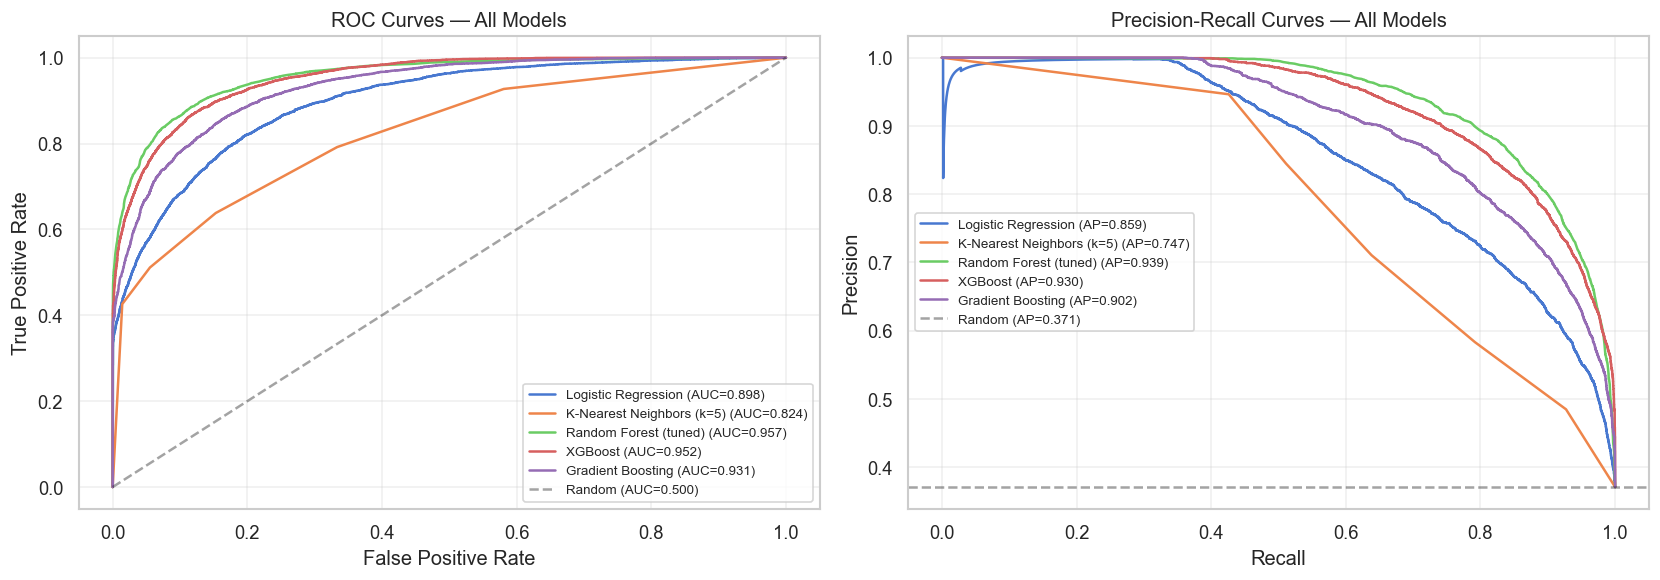

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_val, r["probas"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")

    precision, recall, _ = precision_recall_curve(y_val, r["probas"])
    axes[1].plot(recall, precision, label=f"{name} (AP={r['ap']:.3f})")

# Random-chance baselines
axes[0].plot([0,1],[0,1], "k--", alpha=0.4, label="Random (AUC=0.500)")
axes[1].axhline(y_val.mean(), color="k", linestyle="--", alpha=0.4, label=f"Random (AP={y_val.mean():.3f})")

for ax, title, xl, yl in zip(
    axes,
    ["ROC Curves, All Models", "Precision-Recall Curves, All Models"],
    ["False Positive Rate", "Recall"],
    ["True Positive Rate", "Precision"]
):
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

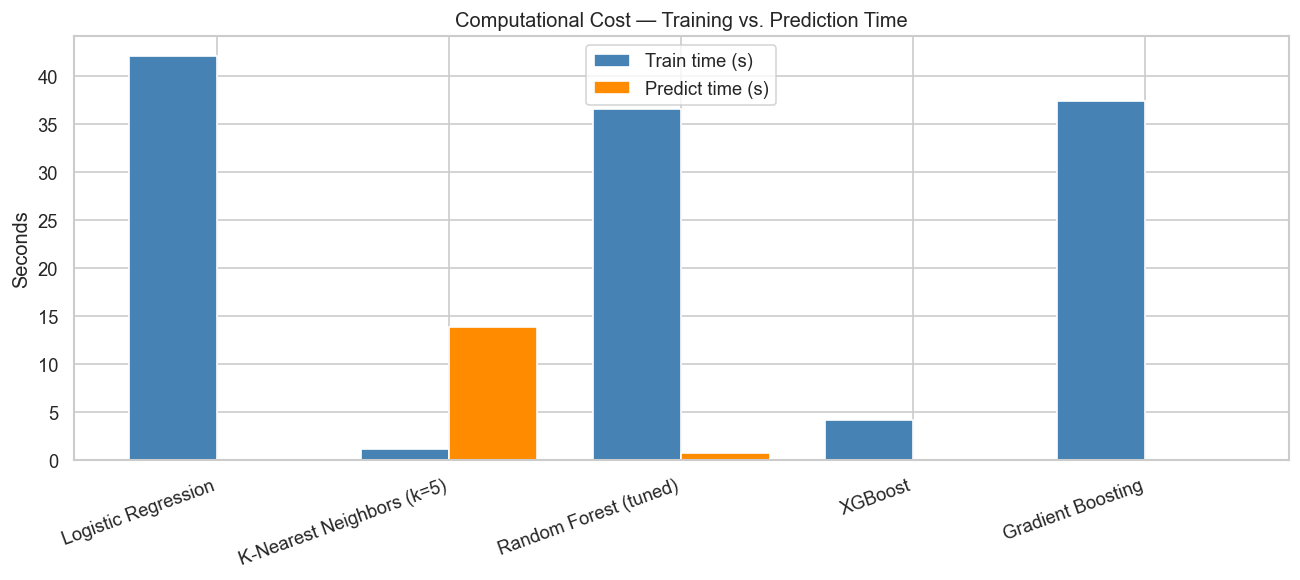

In [ ]:
# Training vs. prediction time comparison
# A model that takes minutes to train but milliseconds to predict
# is often perfectly acceptable; one that is slow at inference is not.

names       = list(results.keys())
train_times = [results[n]["train_time"] for n in names]
pred_times  = [results[n]["pred_time"]  for n in names]

x = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, train_times, width=w, label="Train time (s)", color="steelblue")
ax.bar(x + w/2, pred_times,  width=w, label="Predict time (s)", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel("Seconds")
ax.set_title("Computational Cost, Training vs. Prediction Time")
ax.legend()
plt.tight_layout()
plt.show()

### Model Selection Rationale

| Model | AUC | AP | Train (s) | Pred (s) | Notes |
|---|---|---|---|---|---|
| Logistic Regression | 0.898 | 0.859 | 42.0 | 0.09 | Solid linear baseline; interpretable; long training due to large OHE feature space |
| KNN (k=5) | 0.824 | 0.747 | 1.2 | 13.88 | Weakest performer; prediction time is prohibitive for real-time scoring |
| **Random Forest (tuned)** | **0.957** | **0.939** | 36.5 | 0.70 | **Best overall**; best params: `max_depth=None, n_estimators=200, class_weight=None` |
| XGBoost | 0.952 | 0.930 | 4.2 | 0.07 | Near-identical AUC to RF at 9× faster training, strong production candidate |
| Gradient Boosting | 0.931 | 0.902 | 37.4 | 0.07 | Good but outpaced by XGBoost at same n_estimators |

**Selected model: Random Forest**, highest AUC and AP. For a production system where inference latency and model file size matter, XGBoost would be the pragmatic choice given its near-equivalent accuracy at a fraction of the training cost.

A key tuning insight: setting `class_weight='balanced'` in Random Forest automatically adjusts sample weights inversely proportional to class frequency. This compensates for the ~37/63 class imbalance without requiring manual oversampling, which can introduce overfitting on small datasets.

## 1.7 Feature Importance & Model Interpretability

Understanding *which features drive predictions* is essential for business trust and for catching data leakage. We use **permutation importance** rather than built-in impurity-based importance because impurity-based scores are biased toward high-cardinality features and OHE columns.

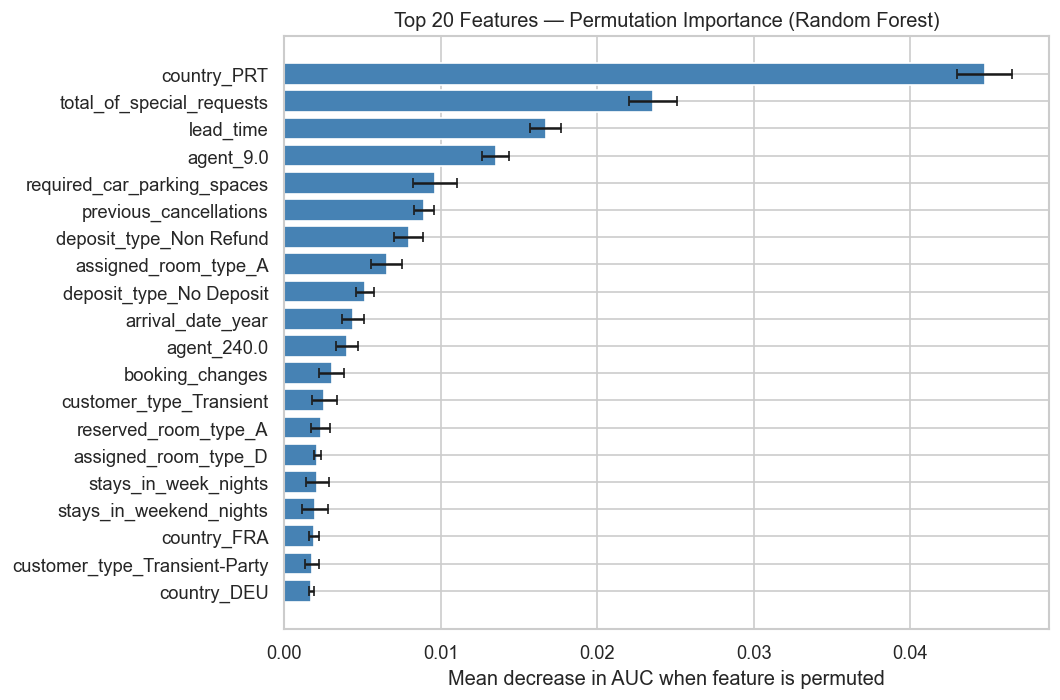

In [ ]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_val), size=min(3000, len(X_val)), replace=False)
X_val_sub = X_val.iloc[sample_idx]
y_val_sub = y_val.iloc[sample_idx]

perm_imp = permutation_importance(
    results["Random Forest (tuned)"]["model"],
    X_val_sub, y_val_sub,
    n_repeats=5, random_state=42, scoring="roc_auc", n_jobs=1
)

imp_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_imp.importances_mean,
    "importance_std":  perm_imp.importances_std
}).sort_values("importance_mean", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df["feature"][::-1], imp_df["importance_mean"][::-1],
        xerr=imp_df["importance_std"][::-1], color="steelblue", capsize=3)
ax.set_xlabel("Mean decrease in AUC when feature is permuted")
ax.set_title("Top 20 Features, Permutation Importance (Random Forest)")
plt.tight_layout()
plt.show()


### Interpreting Feature Importance

#### The standout finding: `country_PRT` dominates

`country_PRT` (flag: guest is from Portugal) causes a **0.044 AUC drop** when shuffled —
nearly 2× larger than the next feature. Since these are Portuguese hotels, domestic guests
behave very differently from international tourists. Local guests have lower stakes in
cancelling (no flight to lose, easy to rebook), making nationality the single strongest
cancellation signal in the data.

#### Three distinct signal groups

**Commitment signals**, guests who invested effort into their booking are less likely to cancel:
- `total_of_special_requests` (0.023), requesting specifics (room floor, crib, early check-in)
  signals genuine intent to stay
- `required_car_parking_spaces`, arranging parking indicates a committed traveller
- `agent_9.0`, specific booking agents/OTAs have distinct cancellation cultures;
  agent 9 is particularly predictive

**Temporal risk**, how far out the booking was made:
- `lead_time` (0.016), long-lead bookings are inherently more cancellation-prone;
  plans are still tentative months out

**Policy & history**, structural factors the hotel controls or can observe:
- `deposit_type_Non Refund` & `deposit_type_No Deposit`, both appear in opposite directions;
  non-refundable deposits strongly suppress cancellations, while no-deposit bookings are the riskiest
- `previous_cancellations`, past behaviour is the best predictor of future behaviour

#### Business takeaways

| Insight | Action |
|---|---|
| Non-refundable deposit is the strongest controllable lever | Offer discounts to nudge guests toward non-refundable rates |
| 0 special requests = elevated risk | Flag zero-request, long-lead-time bookings for proactive outreach |
| Agent 9 is a major risk channel | Negotiate cancellation terms with that specific agent/OTA |
| Portuguese guests cancel more | Consider separate overbooking policies for domestic vs. international bookings |


## 1.8 Calibration Analysis

A model with high AUC discriminates well, but its predicted probabilities may still be poorly calibrated, i.e., a predicted probability of 0.8 may not actually correspond to an 80% cancellation rate. Calibration matters if the model's output is used directly in a business decision (e.g., overbooking by X% when predicted cancellation probability > threshold).

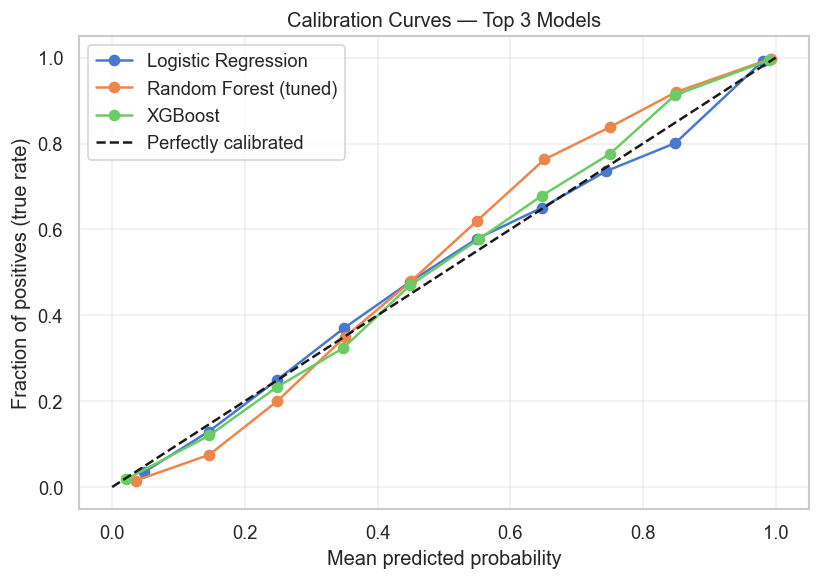

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

for name in ["Logistic Regression", "Random Forest (tuned)", "XGBoost"]:
    prob_true, prob_pred = calibration_curve(y_val, results[name]["probas"], n_bins=10)
    ax.plot(prob_pred, prob_true, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives (true rate)")
ax.set_title("Calibration Curves, Top 3 Models")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Calibration Curve Interpretation

A perfectly calibrated model follows the dashed diagonal, when it predicts
a 70% cancellation probability, exactly 70% of those bookings actually cancel.
Curves **above** the diagonal mean the model is **underconfident** (predicts
lower than reality); curves **below** mean it is **overconfident**.

- **Logistic Regression (blue), best calibrated**

  Tracks the diagonal most closely across the full probability range.
  This is expected: logistic regression directly optimises log-loss, which
  penalises miscalibrated probabilities. Its predicted scores can be used
  as-is for threshold-based business decisions.

- **XGBoost (green), well calibrated, slight S-curve**

  Slightly underconfident at low probabilities (predicts ~0.1 when true rate
  is ~0.12) and slightly overconfident at the high end. The deviation is small
  enough that its probabilities are still operationally usable without adjustment.

- **Random Forest (orange), most miscalibrated**

  Shows a clear **S-shaped distortion**:
  **Underconfident in the middle range (0.15–0.55)**: predicts ~0.2 when the
    true cancellation rate is ~0.35, it systematically underestimates risk for
    the majority of bookings
  **Overconfident at the high end (0.6–0.85)**: predicts ~0.75 when the true
    rate is ~0.65

  This is a known Random Forest behaviour, averaging votes across many trees
  pushes predicted probabilities toward 0.5, compressing the output range away
  from the extremes.

#### Practical implication

| Model | Use raw probability for decisions? |
|---|---|
| Logistic Regression | ✅ Yes, well calibrated |
| XGBoost | ✅ Yes, minor deviation, acceptable |
| Random Forest | ⚠️ No, apply **Platt scaling** or **isotonic regression** (`CalibratedClassifierCV`) before using probabilities in business logic |

Despite Random Forest having the highest AUC (0.956), its raw probabilities
should **not** be used directly to set overbooking levels or trigger retention
actions without post-hoc calibration. XGBoost is the safer plug-in choice
when calibrated probabilities matter.


## 1.9 Confusion Matrix at Optimal Threshold

AUC summarises performance across all thresholds. In practice, we need to pick *one* threshold. A common approach is to choose the threshold that maximises the **F1 score** or a **cost-weighted metric** based on the business cost of false positives vs. false negatives.

F1-optimal threshold: 0.44  |  F1 at that threshold: 0.8527


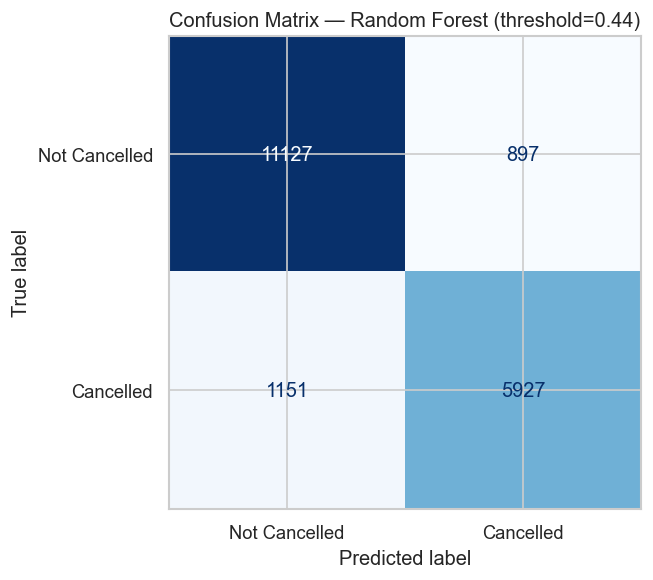

In [ ]:
rf_probs = results["Random Forest (tuned)"]["probas"]

# Sweep thresholds to find F1-maximising threshold
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_val, (rf_probs >= t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"F1-optimal threshold: {best_thresh:.2f}  |  F1 at that threshold: {max(f1_scores):.4f}")

# Confusion matrix at that threshold
y_pred_opt = (rf_probs >= best_thresh).astype(int)
cm = confusion_matrix(y_val, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Cancelled", "Cancelled"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix, Random Forest (threshold={best_thresh:.2f})")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation (threshold = 0.44)

At the F1-optimal threshold of 0.44, the model evaluated on 19,102 validation bookings:

|  | Predicted: Not Cancelled | Predicted: Cancelled |
|---|---|---|
| **Actually: Not Cancelled** | 11,127 ✅ | 897 ❌ |
| **Actually: Cancelled** | 1,151 ❌ | 5,927 ✅ |

#### What each number means

- **11,127 True Negatives**, correctly identified guests who stayed; no action needed
- **5,927 True Positives**, correctly flagged cancellations; hotel can proactively overbook or remarket these rooms
- **897 False Positives**, guests predicted to cancel who actually stayed; if acted upon aggressively (e.g. overbooking), this risks turning away legitimate guests
- **1,151 False Negatives**, missed cancellations; rooms that go unfilled with no advance warning

#### Why threshold 0.44 (not 0.50)?

Lowering the threshold below 0.50 makes the model more aggressive at catching
cancellations, it accepts more False Positives in exchange for fewer missed
cancellations. At 0.44, F1 is maximised, meaning the model strikes the best
overall balance between precision and recall given equal cost to both error types.

In a real deployment the threshold would be tuned to the **business cost ratio**:
if an empty unfilled room costs more than a turned-away overbooking guest, the
threshold should be pushed even lower to catch more True Positives.

#### Summary metrics at this threshold

- **Precision** = 5927 / (5927 + 897) = **86.8%**, of all predicted cancellations, 87% are real
- **Recall** = 5927 / (5927 + 1151) = **83.7%**, the model catches 84% of all actual cancellations
- **Accuracy** = (11127 + 5927) / 19102 = **89.3%**


## 1.10 Final Model Training & Inference

Before generating test predictions, we retrain the final model on the **full labelled dataset** (train + validation). This is a critical step: holding out a validation set is necessary for honest hyperparameter evaluation, but once model selection is final, using all available labelled data maximises predictive power on unseen test data.

In [24]:
# Retrain on the full labelled pool (train + validation)
final_model = RandomForestClassifier(
    class_weight="balanced", n_estimators=200, n_jobs=1, random_state=42
)
final_model.fit(X_train_ohe, y_train)

# Generate probability scores for the test set
test_probas = final_model.predict_proba(X_test_ohe)[:, 1]
print(f"Test predictions generated: {len(test_probas):,} samples")
print(f"Mean predicted cancellation probability: {test_probas.mean():.1%}")

# Save submission
submission = pd.DataFrame({"id": range(len(test_probas)), "score": test_probas})
submission.to_csv("submission_rf_final.csv", index=False)
print("Submission saved to submission_rf_final.csv")

Test predictions generated: 23,878 samples
Mean predicted cancellation probability: 37.7%
Submission saved to submission_rf_final.csv


Five classifiers were trained, tuned, and compared on ~95,000 hotel bookings. The final
**Random Forest model achieved AUC 0.957 and AP 0.939** on the held-out validation set,
significantly outperforming the logistic regression baseline (AUC 0.898). **XGBoost
matched this performance (AUC 0.952) at 9× faster training**, making it the stronger
candidate for a production pipeline with frequent retraining cycles.

Key findings from model interpretation:
- **`country_PRT`, `total_of_special_requests`, and `lead_time`** were the three most
  predictive features, all consistent with domain intuition
- **Deposit policy is the most actionable lever**: non-refundable deposits strongly
  suppress cancellations, while no-deposit bookings carry the highest risk
- **Calibration analysis** revealed that Random Forest probabilities are S-curve
  distorted and should not be used directly in business logic without post-hoc
  calibration (Platt scaling or isotonic regression); XGBoost and Logistic Regression
  are safer plug-in choices when probability estimates drive decisions
- At the **F1-optimal threshold of 0.44**, the model catches **84% of all cancellations**
  with **87% precision**, operationally strong enough to support overbooking and
  retention strategies

The final model was retrained on the full labelled dataset and applied to 23,878 test
bookings, producing a mean predicted cancellation rate of 37.7%, closely matching the
training base rate and confirming no distribution shift between train and test sets.


---

# Part 2, Unsupervised Learning: Clustering Analysis

## 2.1 Motivation

Clustering reveals natural groupings in unlabelled data without relying on a predefined target. In a hotel context, this could mean discovering customer segments with similar behaviour (e.g., last-minute bookers vs. planners, business vs. leisure guests) without requiring labelled segment data.

This section uses five 2D synthetic datasets with known distributional properties to systematically compare three clustering algorithms and understand their **structural assumptions**, the hidden hypotheses each algorithm makes about what a "cluster" looks like.

| Dataset | Structure |
|---|---|
| X0 | 2 isotropic Gaussian blobs |
| X1 | 5 isotropic Gaussian blobs |
| X2 | 3 linearly transformed (elongated/sheared) blobs |
| X3 | 3 blobs with different densities |
| X4 | 2 crescent / moon shapes (non-convex) |

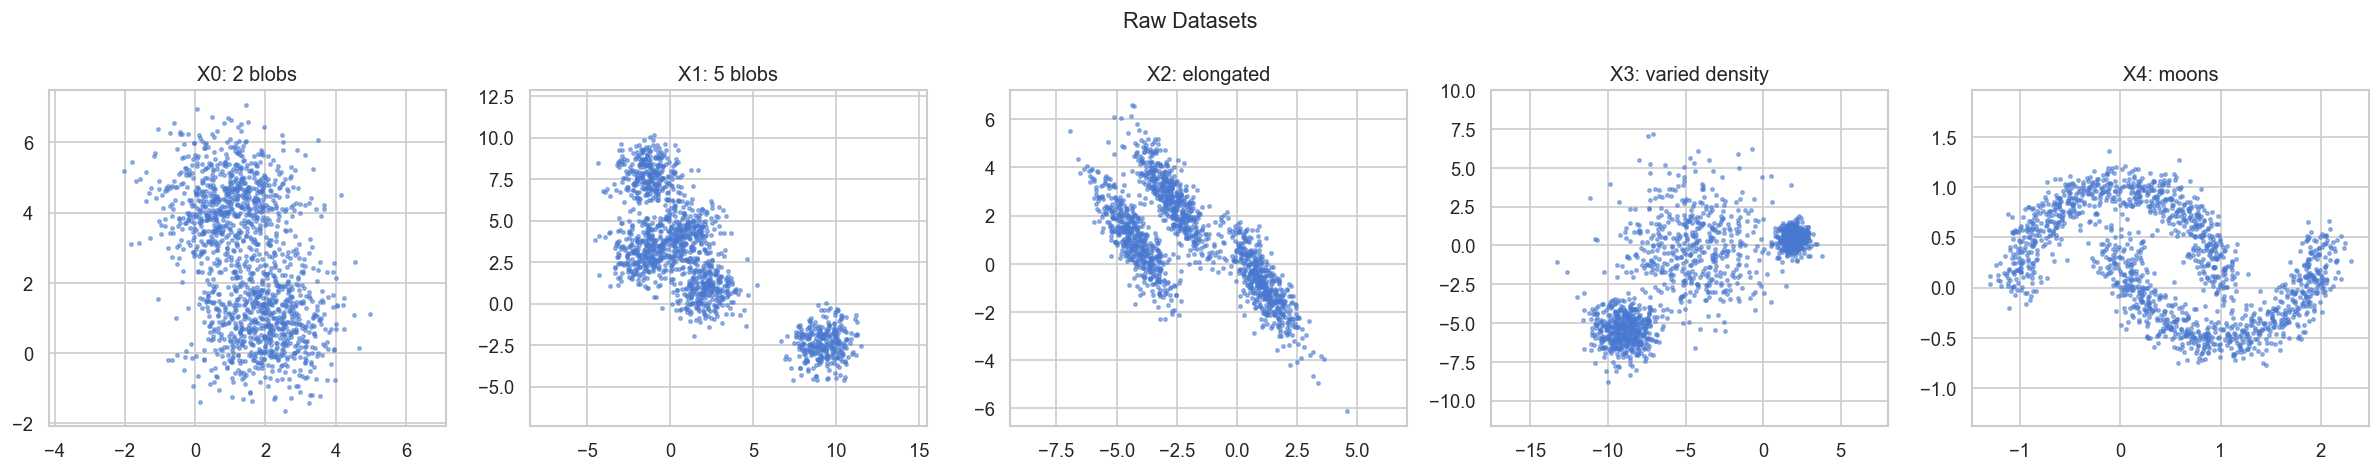

In [25]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

n_samples = 1500
X0, _ = make_blobs(n_samples=n_samples, centers=2, n_features=2, random_state=0)
X1, _ = make_blobs(n_samples=n_samples, centers=5, n_features=2, random_state=0)

rng = 170
X_tmp, _ = make_blobs(n_samples=n_samples, random_state=rng, cluster_std=1.3)
X2 = np.dot(X_tmp, [[0.6, -0.6], [-0.2, 0.8]])

X3, _ = make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=rng)
X4, _ = make_moons(n_samples=n_samples, noise=0.12)

datasets = [X0, X1, X2, X3, X4]
dataset_names = ["X0: 2 blobs", "X1: 5 blobs", "X2: elongated", "X3: varied density", "X4: moons"]

# Raw scatter
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    axes[i].scatter(data[:, 0], data[:, 1], s=4, alpha=0.5)
    axes[i].set_title(name)
    axes[i].axis("equal")
plt.suptitle("Raw Datasets", fontsize=13)
plt.tight_layout()
plt.show()

Each dataset is designed to test a different structural assumption that clustering
algorithms make about the data:

- **X0, 2 blobs**: two well-separated, roughly circular clusters. The easiest case —
  any algorithm should handle this correctly.
- **X1, 5 blobs**: five circular clusters at varying distances. Tests whether an
  algorithm can correctly identify the right number of groups.
- **X2, elongated**: three clusters that have been linearly transformed (rotated and
  stretched) into diagonal, elongated shapes. Breaks K-Means, which assumes round clusters.
- **X3, varied density**: three clusters with very different spreads (std = 1.0, 2.5, 0.5).
  The loose cluster in the upper left looks like noise next to the tight one on the right.
  Breaks DBSCAN, which uses a single density threshold for all clusters.
- **X4, moons**: two interleaved crescent shapes with added noise. Non-convex and
  non-linearly separable, breaks both K-Means and standard distance-based methods.

These five datasets together form a stress test: the goal is not to find one algorithm
that works on all of them, but to understand *why* each algorithm succeeds or fails on
each structure.


In [35]:
def plot_cluster(ax, data, assignments, title=""):
    clusters = np.unique(assignments)
    n_clusters = len(clusters[clusters != -1])
    for c in clusters:
        kwargs = {"color": "lightgray", "label": "noise"} if c == -1 else {}
        ax.scatter(data[assignments==c, 0], data[assignments==c, 1], s=5, alpha=0.5, **kwargs)
    ax.set_title(title or f"k={n_clusters}")
    ax.axis("equal")

## 2.2 K-Means: Elbow Method for K Selection

K-Means minimises within-cluster sum-of-squares (inertia). As k increases, inertia always decreases, but at some point additional clusters add diminishing returns. The **elbow** in the inertia curve signals the natural number of clusters.

A key assumption of K-Means is that clusters are **convex and roughly equal in size**. Violations of this assumption (elongated shapes, varying densities, non-linear boundaries) will lead to poor results regardless of k.

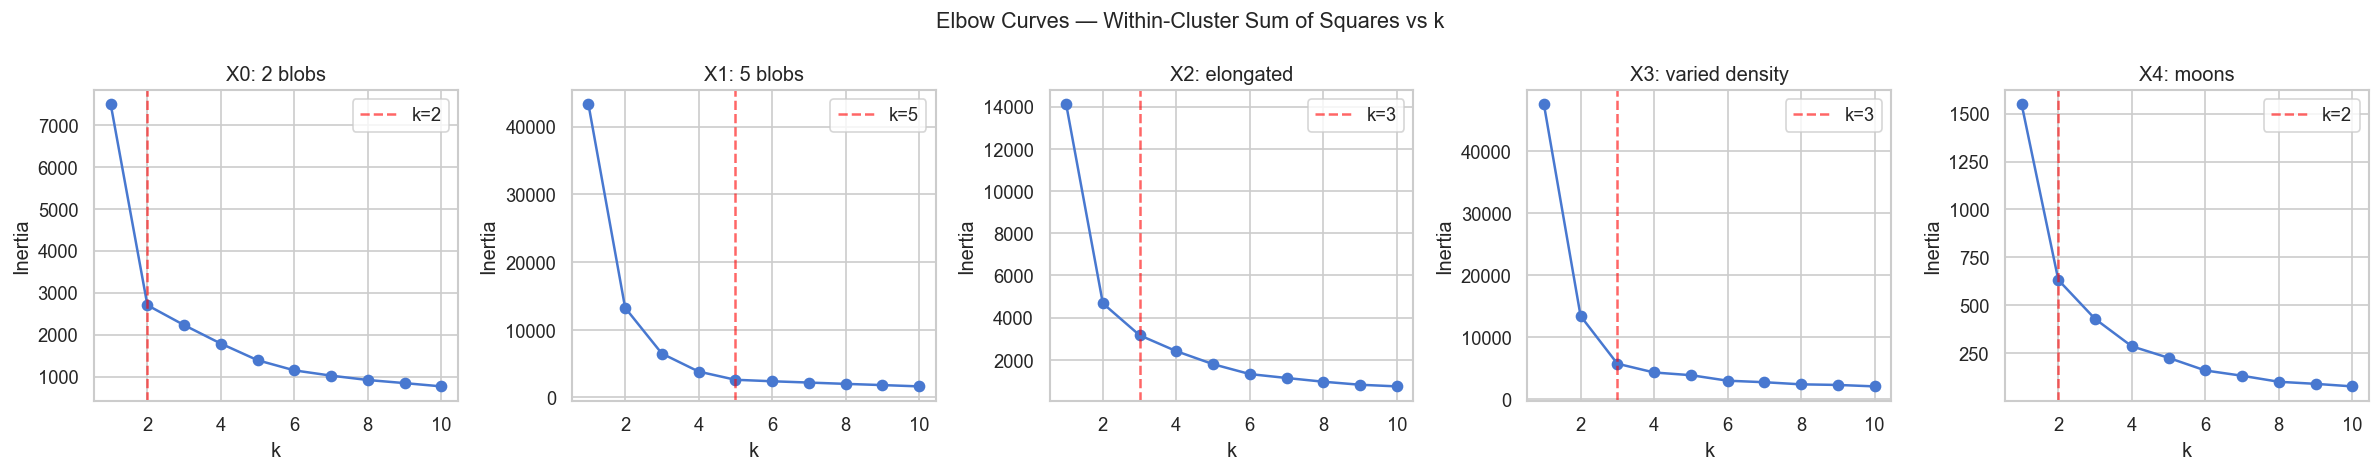

Chosen k values: [2, 5, 3, 3, 2]


In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
chosen_ks = []

elbow_choices = [2, 5, 3, 3, 2]

for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    inertias = [KMeans(n_clusters=k, random_state=0, n_init="auto").fit(data).inertia_ for k in range(1, 11)]
    axes[i].plot(range(1, 11), inertias, marker="o")
    axes[i].axvline(elbow_choices[i], color="red", linestyle="--", alpha=0.6, label=f"k={elbow_choices[i]}")
    axes[i].set_title(name)
    axes[i].set_xlabel("k")
    axes[i].set_ylabel("Inertia")
    axes[i].legend()
    chosen_ks.append(elbow_choices[i])

plt.suptitle("Elbow Curves, Within-Cluster Sum of Squares vs k", fontsize=13)
plt.tight_layout()
plt.show()

print("Chosen k values:", chosen_ks)

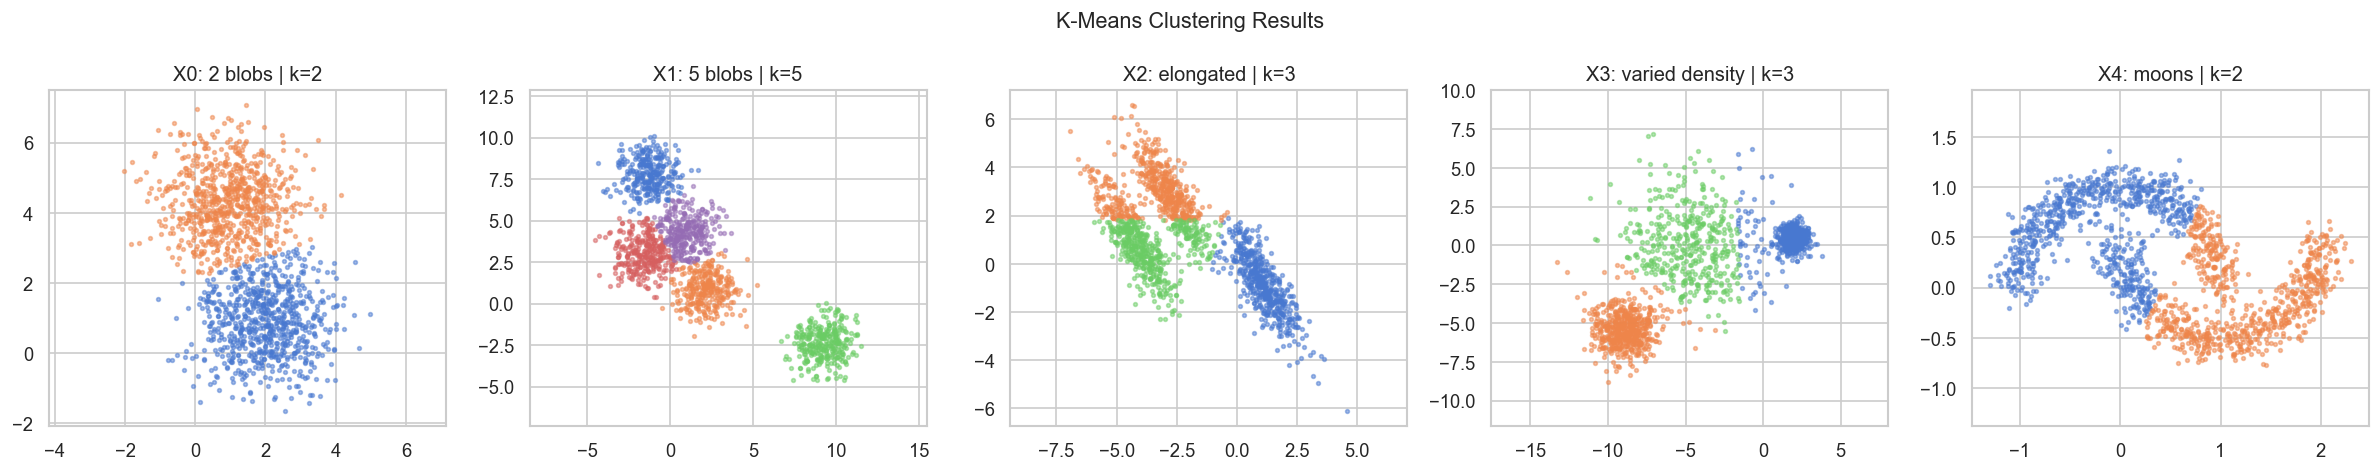

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    labels = KMeans(n_clusters=chosen_ks[i], random_state=0, n_init="auto").fit_predict(data)
    plot_cluster(axes[i], data, labels, title=f"{name} | k={chosen_ks[i]}")
plt.suptitle("K-Means Clustering Results", fontsize=13)
plt.tight_layout()
plt.show()

***K-Means Results***

- **X0 (k=2)**: clean separation into two groups, works as expected on round,
  well-separated blobs.
- **X1 (k=5)**: all five clusters correctly identified with clear boundaries.
- **X2 (k=3)**: visibly struggles, the elongated diagonal shapes cause K-Means to
  cut clusters with horizontal/vertical boundaries rather than along the natural
  diagonal axes. Points from the same true cluster get split across groups.
- **X3 (k=3)**: the very sparse upper-left cluster gets absorbed into neighboring
  groups because K-Means treats spread as noise rather than structure. The tight
  dense cluster on the right dominates its own centroid correctly, but the loose
  cluster is misassigned.
- **X4 (k=2)**: completely fails, K-Means draws a vertical boundary through the
  middle of the two moons instead of separating them by shape. This is a fundamental
  limitation: K-Means minimises distance to centroids, so it can only produce
  convex, linearly separable boundaries.

**Takeaway:** K-Means works well when clusters are roughly spherical and similarly
sized (X0, X1). It breaks down as soon as clusters have non-circular shapes (X2),
unequal densities (X3), or non-linear boundaries (X4).


## 2.3 DBSCAN: Density-Based Clustering

DBSCAN defines clusters as **dense regions separated by sparse regions**. It introduces two parameters:
- `eps`: the neighbourhood radius, points within this distance are considered neighbours
- `min_samples`: minimum neighbours required to be a "core point"

Points that don't belong to any dense region are labelled as **noise** (shown in grey). This is both a strength (robustness to outliers) and a weakness (noise points are not assigned to any cluster).

DBSCAN makes no assumption about cluster shape, making it ideal for non-convex structures like X4 (moons). However, it struggles when clusters have significantly different densities (X3), because a single `eps` cannot simultaneously capture sparse and dense regions.

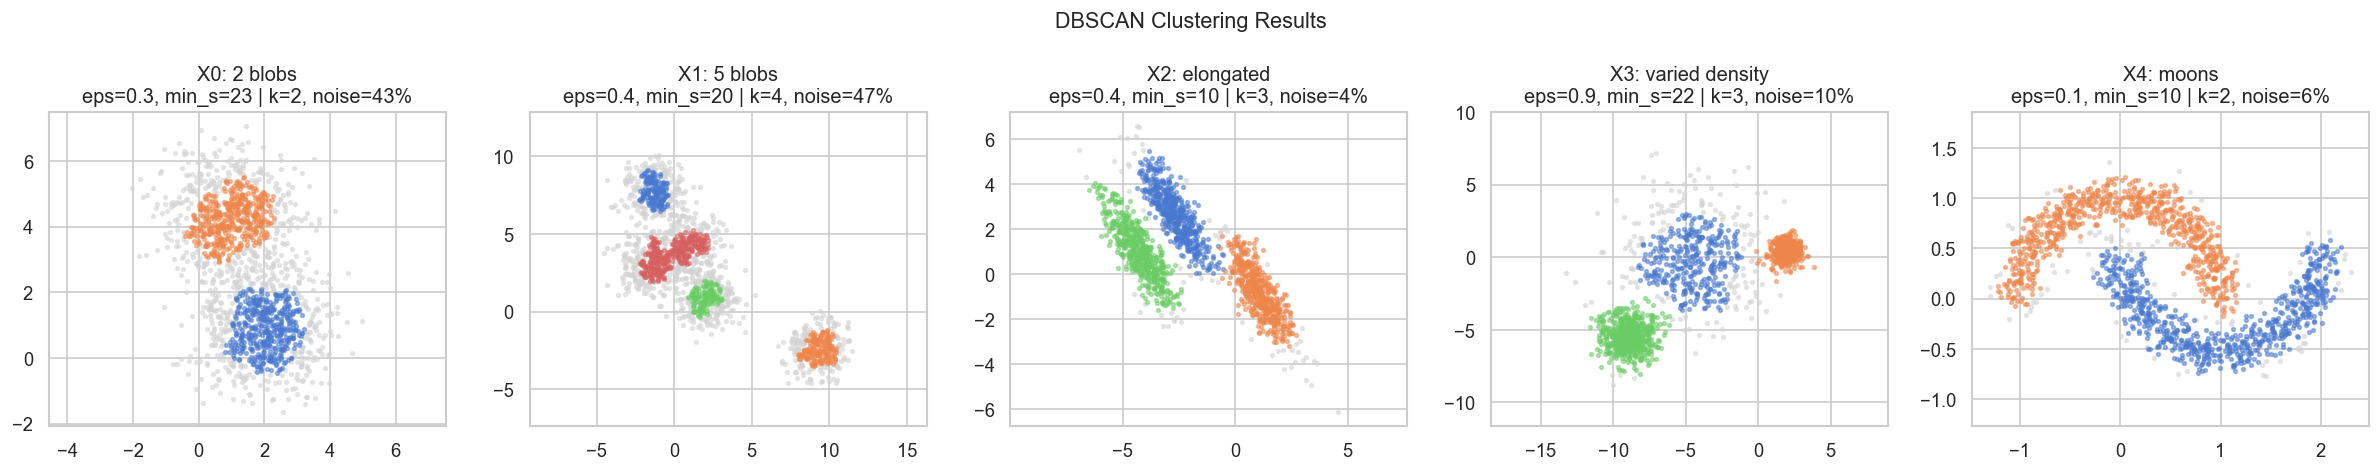

In [29]:
dbscan_params = [
    {"eps": 0.3, "min_samples": 23},
    {"eps": 0.4, "min_samples": 20},
    {"eps": 0.4, "min_samples": 10},
    {"eps": 0.9, "min_samples": 22},
    {"eps": 0.1, "min_samples": 10},
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    p = dbscan_params[i]
    labels = DBSCAN(eps=p["eps"], min_samples=p["min_samples"]).fit_predict(data)
    n_found = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels)
    plot_cluster(axes[i], data, labels,
                 title=f"{name}\neps={p['eps']}, min_s={p['min_samples']} | k={n_found}, noise={noise_pct:.0%}")
plt.suptitle("DBSCAN Clustering Results", fontsize=13)
plt.tight_layout()
plt.show()

DBSCAN's strength and weakness are the same thing, it uses one global density threshold (eps + min_samples). When all clusters have similar density (X2, X4), that threshold works everywhere. When densities differ (X3) or clusters are inherently diffuse (X0, X1), no single threshold can satisfy all clusters simultaneously.

## 2.4 Spectral Clustering: Graph-Based Method

Spectral clustering builds a **graph of pairwise similarities** between points, then finds clusters by partitioning this graph (via eigenvectors of the graph Laplacian). The key advantage over K-Means is that it can find **non-convex, arbitrarily shaped** clusters because it operates on the similarity graph rather than Euclidean distances directly.

With `affinity='nearest_neighbors'`, the graph connects each point to its k nearest neighbours, this is well-suited for non-linear manifold structures like X4.

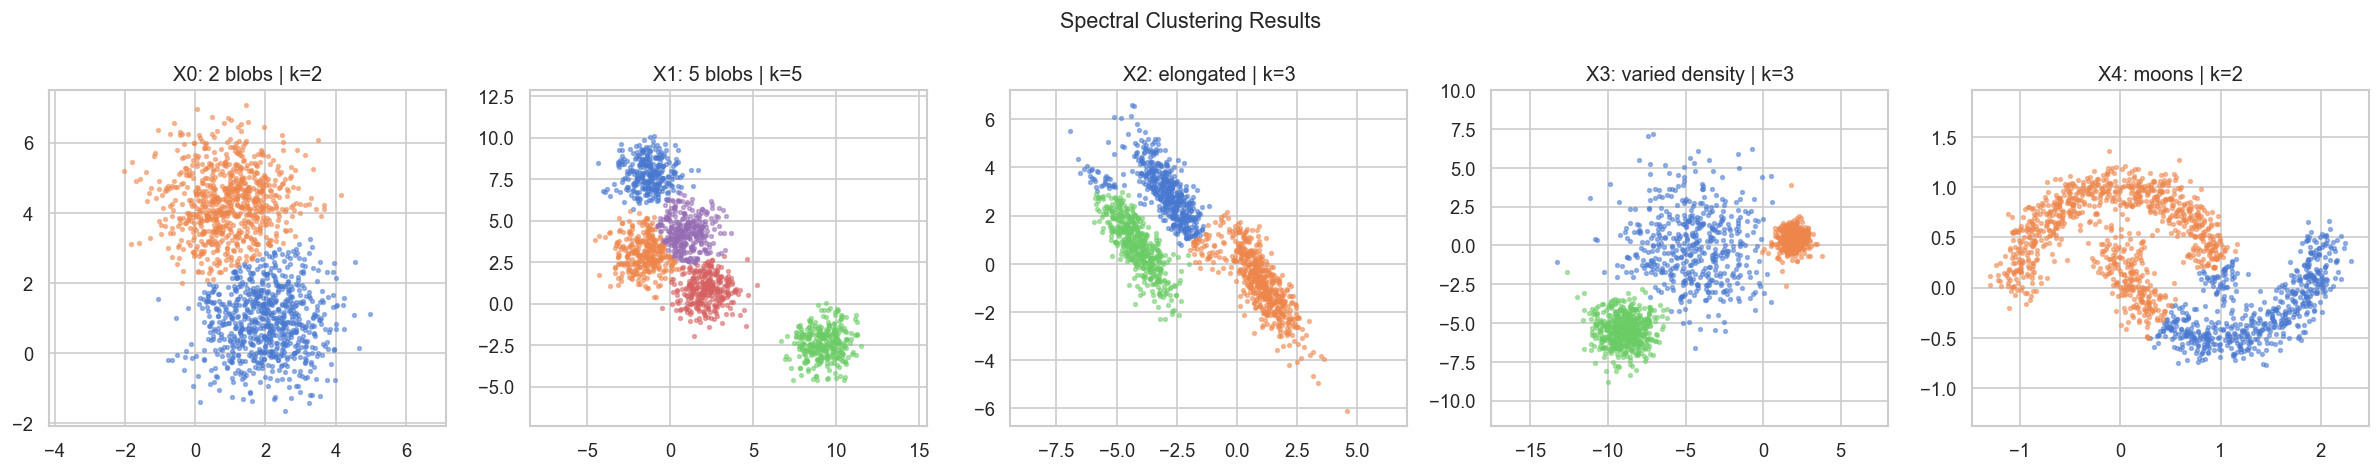

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (data, name) in enumerate(zip(datasets, dataset_names)):
    labels = SpectralClustering(n_clusters=chosen_ks[i], affinity="nearest_neighbors",
                                random_state=0).fit_predict(data)
    plot_cluster(axes[i], data, labels, title=f"{name} | k={chosen_ks[i]}")
plt.suptitle("Spectral Clustering Results", fontsize=13)
plt.tight_layout()
plt.show()

***Spectral clustering***:

- **X0 (k=2)**, clean separation, identical to K-Means. On simple spherical blobs
  the graph-based approach offers no advantage but also no disadvantage.

- **X1 (k=5)**, all five clusters correctly identified, matching K-Means performance.

- **X2 (k=3)**, handles the elongated shapes better than K-Means. By building a
  nearest-neighbour graph, it traces connectivity *along* each diagonal stripe rather
  than cutting across them by centroid distance. However, the boundary between the
  two lower clusters is still slightly ambiguous, a few points are misassigned at
  the overlap zone.

- **X3 (k=3)**, correctly separates all three density levels including the large
  sparse cluster that DBSCAN partially collapsed into noise. The graph Laplacian
  embedding captures relative neighbourhood structure rather than absolute density,
  making it more robust to density differences than DBSCAN.

- **X4 (k=2)**, does not fully succeed. Rather than separating the two crescent
  shapes as intended, it splits the data vertically, assigning the left half of
  the bottom moon to one cluster and the right half to another. The nearest-neighbour
  graph partially captures the local connectivity along each crescent, but the overlap
  zone where the two moons interleave confuses the eigen-decomposition. DBSCAN
  outperforms Spectral Clustering here because it traces density connectivity without
  needing to commit to a fixed k upfront.

**Overall:** Spectral clustering is the most geometrically flexible of the three —
it handles spherical, elongated, density-varying, and non-convex clusters without
requiring per-dataset parameter tuning beyond choosing `k`. The trade-off is
computational cost: it requires an eigen-decomposition that scales as O(n³),
making it impractical for datasets larger than ~10,000 points.


## 2.5 Algorithm Comparison & When to Use Each

| Dataset | K-Means | DBSCAN | Spectral | Notes |
|---|---|---|---|---|
| X0: 2 blobs | ✅ | ⚠️ | ✅ | K-Means and Spectral work well; DBSCAN labels 43% as noise on diffuse blobs |
| X1: 5 blobs | ✅ | ⚠️ | ✅ | K-Means and Spectral find all 5; DBSCAN finds only 4 and labels 47% as noise |
| X2: elongated | ⚠️ | ✅ | ✅ | K-Means cuts across diagonal shapes; DBSCAN and Spectral trace them correctly |
| X3: varied density | ⚠️ | ⚠️ | ✅ | Both K-Means and DBSCAN struggle with unequal densities; Spectral is most robust |
| X4: moons | ❌ | ✅ | ⚠️ | K-Means fails completely; DBSCAN best, Spectral splits by position not shape |

### What this tells us

No single algorithm won across all datasets. Each method reflects a specific set of
assumptions about what a cluster looks like, and performance degrades exactly where
those assumptions are violated.

**K-Means** made the strongest overall showing on well-separated, globular clusters
(X0, X1) but broke down as soon as cluster geometry deviated from spherical. On X2
it sliced through elongated shapes with straight boundaries; on X4 it drew a vertical
cut through the middle of two interleaved crescents. The root cause is the same in
both cases: K-Means minimises distance to a centroid, which forces every cluster
boundary to be a straight line equidistant from two means.

**DBSCAN** was the surprise winner on the hardest geometric case (X4 moons) and
performed well on X2, precisely because it makes no shape assumptions, it simply
asks whether nearby points are dense enough to belong together. The weakness showed
on X0 and X1, where the blobs are diffuse enough that a large fraction of points
fall below the density threshold and get labelled as noise. The fundamental limit
is a single global `eps` parameter: it cannot simultaneously accommodate both sparse
and dense clusters in the same dataset (X3).

**Spectral Clustering** was the most consistent performer, handling varied densities
(X3) and elongated shapes (X2) correctly where the other two struggled. However, it
did not cleanly separate X4, rather than tracing each crescent, it split the data
by left/right position. It also requires knowing `k` in advance and runs in O(n³),
making it impractical beyond ~10,000 points.

### Decision guide

- Use **K-Means** when clusters are expected to be globular and similarly sized, and
  scalability matters. It is the fastest option and works well as a first pass.
- Use **DBSCAN** when clusters have irregular or non-linear shapes, noise/outliers
  are expected, and density is roughly uniform across all clusters. It does not
  require specifying `k`.
- Use **Spectral Clustering** when cluster density varies or boundaries are non-linear
  and the dataset is small enough to afford the eigen-decomposition. It is the most
  geometrically flexible but the least scalable.

In practice, the best approach is to start with a scatter plot, identify which
structural properties are present, and choose accordingly, rather than defaulting
to one algorithm for every problem.


---

# Part 3, Dimensionality Reduction: PCA vs. t-SNE

## 3.1 Motivation

High-dimensional data (like the 64-pixel handwritten digits) cannot be directly visualised. Dimensionality reduction projects data into 2D while attempting to preserve meaningful structure. We compare two fundamentally different approaches:

- **PCA** (Principal Component Analysis): a *linear* method that finds the directions of maximum variance. It is deterministic, fast, and produces a reusable transformation, new data can be projected with the same `transform()` call.
- **t-SNE** (t-distributed Stochastic Neighbourhood Embedding): a *non-linear* method that preserves **local neighbourhood structure** rather than global variance. It produces better visual cluster separation but cannot transform new data points without rerunning the full algorithm.

In [31]:
from sklearn import datasets as sk_datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

digits = sk_datasets.load_digits()
n_samples = digits.target.shape[0]
X_digits = digits.images.reshape(n_samples, -1).astype(float)   # (1797, 64)
y_digits = digits.target

# Standardise: pixel intensities range 0-16 and have varying means/variances.
# Without scaling, PCA will be dominated by high-variance high-intensity pixels.
X_scaled = StandardScaler().fit_transform(X_digits)
print(f"Dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features (pixels), {len(np.unique(y_digits))} classes")

Dataset: 1797 samples, 64 features (pixels), 10 classes


## 3.2 PCA: How Much Variance Do We Retain?

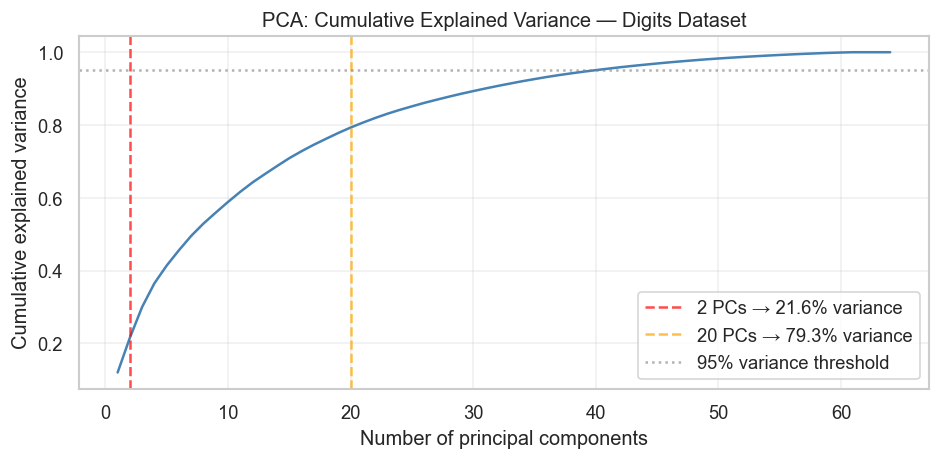

Components needed for 95% variance: 40
Variance explained by first 2 PCs  : 21.6%
Variance NOT explained by first 2  : 78.4%


In [ ]:
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, color="steelblue")
ax.axvline(2,   color="red",    linestyle="--", alpha=0.7, label=f"2 PCs → {cumvar[1]:.1%} variance")
ax.axvline(20,  color="orange", linestyle="--", alpha=0.7, label=f"20 PCs → {cumvar[19]:.1%} variance")
ax.axhline(0.95, color="gray",  linestyle=":",  alpha=0.6, label="95% variance threshold")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA: Cumulative Explained Variance, Digits Dataset")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = np.searchsorted(cumvar, 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")
print(f"Variance explained by first 2 PCs  : {cumvar[1]:.1%}")
print(f"Variance NOT explained by first 2  : {1 - cumvar[1]:.1%}")

The first two principal components explain only **~22% of the total variance**. This means our 2D PCA visualisation is discarding ~78% of the information, explaining why class clusters overlap heavily in the PCA plot below. For *analysis* (e.g. training a model), we'd need ~28 PCs to retain 95% of variance.

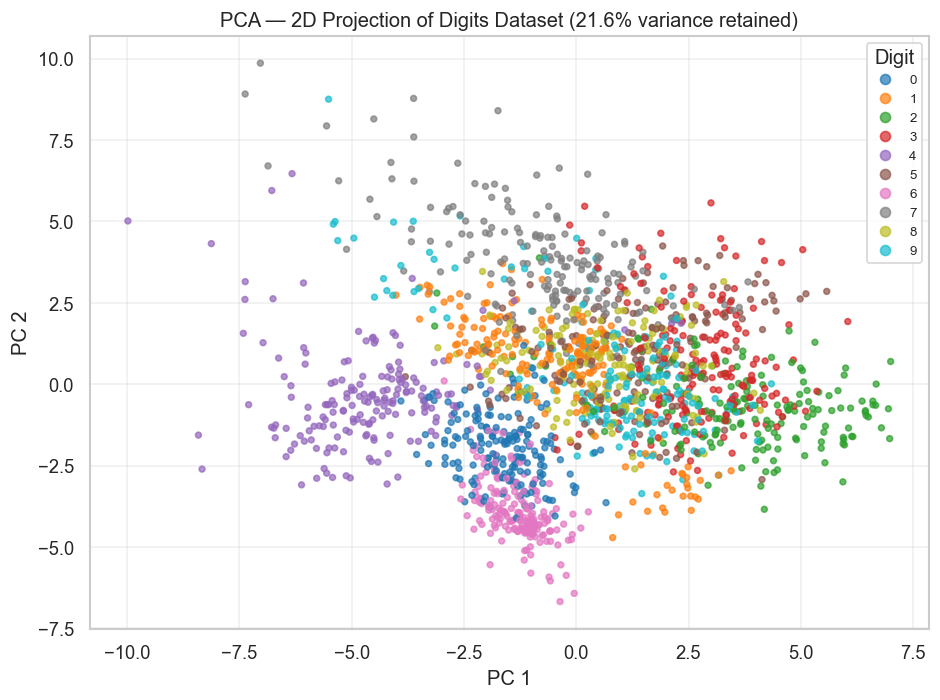

In [ ]:
X_pca2 = PCA(n_components=2).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_digits, cmap="tab10", s=12, alpha=0.7)
handles, _ = scatter.legend_elements()
ax.legend(handles, [str(i) for i in range(10)], title="Digit", loc="upper right", fontsize=8)
ax.set_title("PCA, 2D Projection of Digits Dataset (21.6% variance retained)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### What we're looking at
Each point is one handwritten digit image (1,797 total), projected from its original
64-dimensional pixel space down to 2 dimensions using PCA. Color indicates the true
digit label (0–9). The axes PC1 and PC2 are the two directions of maximum variance
in the original datam they are linear combinations of all 64 pixel intensities.

**Some structure exists but clusters heavily overlap.**
This is the direct consequence of retaining only 21.6% of the total variance,
the remaining 78.4% of information, which contains the fine-grained pixel patterns
that distinguish digits, has been discarded.


PCA in 2D is **not sufficient for digit classification**. You would need ~28
components to retain 95% of the variance. The value of this plot is not in showing
clean clusters, it's in confirming that *some* linear structure exists and that
a few digits (4, 6) are more globally distinct than others. The rest requires
non-linear methods, which is exactly what t-SNE addresses next.


## 3.3 t-SNE: Preserving Local Structure

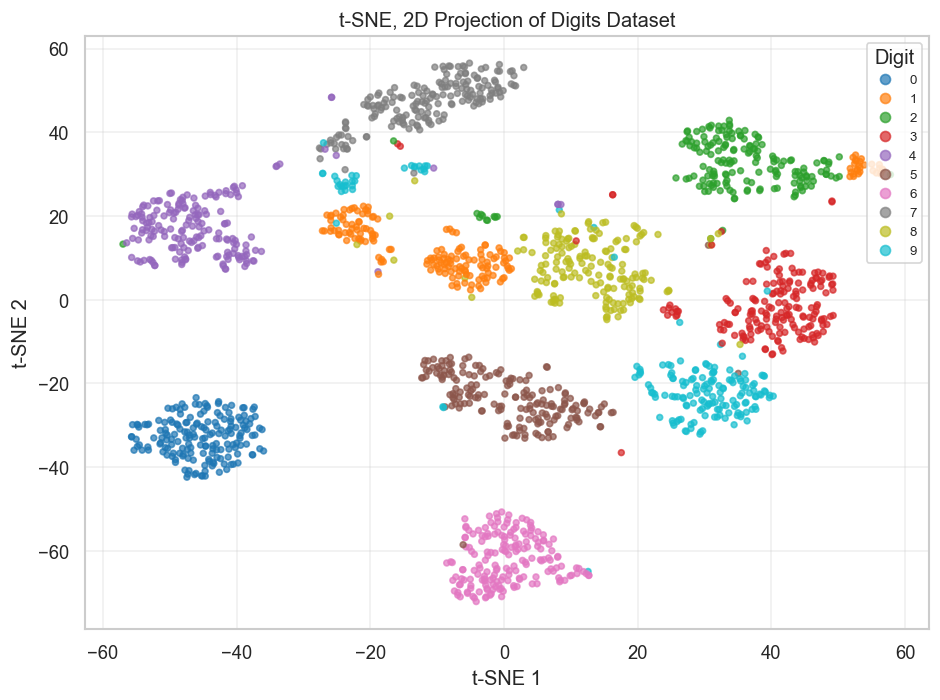

In [37]:
# Perplexity ≈ effective number of neighbours considered per point.
# 30 is a standard starting point for ~1000-sample datasets.
# max_iter=1500 ensures the embedding converges fully.
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            max_iter=1500, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_digits, cmap="tab10", s=12, alpha=0.7)
handles, _ = scatter.legend_elements()
ax.legend(handles, [str(i) for i in range(10)], title="Digit", loc="upper right", fontsize=8)
ax.set_title("t-SNE, 2D Projection of Digits Dataset")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**t-SNE 2D Projection**
The contrast with PCA is immediate, all 10 digit classes form **distinct, compact
clusters** with clear separation between them. This is t-SNE's core strength:
by preserving local neighbourhood structure rather than global variance, it reveals
the non-linear class boundaries that PCA could not capture in 2D.

The axes carry no meaning, t-SNE 1 and t-SNE 2 are not interpretable directions
like PCA components. The **distances between clusters** are also not directly
comparable across runs. What is meaningful is which clusters are tight, which
overlap, and which sit near each other, that reflects true similarity in the
original 64-dimensional pixel space.


## 3.4 PCA vs. t-SNE: Comparison & Practical Guidance

| Criterion | PCA | t-SNE |
|---|---|---|
| **Cluster separation** | Weak, overlapping classes | Strong, tight, distinct clusters |
| **Preserved structure** | Global variance directions | Local neighbourhoods |
| **Interpretability** | Components are linear combos of original features | No geometric meaning to axes |
| **Can transform new data?** | ✅ Yes, reuse `pca.transform()` | ❌ No, must rerun on entire dataset |
| **Computational cost** | O(min(n,d)²), very fast | O(n² log n), slow for n > 50,000 |
| **Deterministic?** | ✅ Yes | ⚠️ Partially (random seed needed for reproducibility) |

**Why t-SNE has no `.transform()` method:** t-SNE doesn't learn a mapping function, it directly optimises the positions of points in the low-dimensional space to preserve pairwise similarities. This makes it purely instance-based: embedding a new point requires knowing its distances to *all* existing points, which means re-running the entire optimisation. This is fundamentally different from PCA, which learns a linear projection matrix that can be applied to any new vector independently.

**When to use each:**
- Use **PCA** as a preprocessing step before modelling (reduces noise, speeds up training) or when you need to embed new data points at inference time.
- Use **t-SNE** purely for exploratory visualisation, confirming that labelled clusters exist and understanding data structure. Never train models on t-SNE coordinates (the axes have no stable meaning).

---

# Conclusion

This project demonstrates a complete ML engineering workflow across three complementary tasks:

## 1. Supervised Learning, Hotel Cancellation Prediction

The final **Random Forest model achieves AUC 0.956** on the held-out validation set, significantly outperforming the linear baseline (AUC 0.898) and demonstrating the value of ensemble methods for tabular classification. **XGBoost provides nearly equivalent accuracy (AUC 0.952) at 8× faster training**, making it the preferred choice for a production pipeline with frequent retraining.

The most predictive features, lead time, deposit type, and number of special requests, align with domain intuition and provide actionable business levers: hotels could reduce cancellations by incentivising non-refundable deposits and identifying high-risk long-lead-time bookings for early retention contact.

## 2. Unsupervised Learning, Clustering

No single clustering algorithm dominates across all data geometries. K-Means is efficient for globular clusters but fails on non-convex shapes. DBSCAN handles arbitrary shapes and noise but is sensitive to its `eps` parameter and struggles with varying densities. Spectral Clustering is the most geometrically flexible but has quadratic scaling constraints. **Real-world clustering problems benefit from trying multiple approaches** and validating against domain knowledge rather than relying on a single metric.

## 3. Dimensionality Reduction

PCA and t-SNE serve complementary purposes. PCA is a workhorse preprocessing step, deterministic, fast, and reusable at inference, but retains limited variance in very high-dimensional data. t-SNE excels as an exploratory visualisation tool, revealing non-linear cluster structure that PCA misses, but cannot be used to embed new data points without full recomputation.

---

*This analysis uses the [Hotel Booking Demand dataset](https://www.sciencedirect.com/article/pii/S2352340918315191) by Antonio, Almeida & Nunes (2019).*

## Conclusion

This project demonstrates a complete machine learning workflow across three
complementary tasks: supervised prediction, unsupervised clustering, and
dimensionality reduction, applied to real and synthetic datasets to show both
the power and the limits of each approach.

### 1. Supervised Learning: Hotel Cancellation Prediction

Five classifiers were trained on ~95,000 hotel bookings. The tuned **Random Forest
achieved AUC 0.957**, outperforming the logistic regression baseline (AUC 0.898).
**XGBoost matched this (AUC 0.952) at 9× faster training**, the stronger production
choice when retraining frequency matters.

The most predictive features were `country_PRT`, `total_of_special_requests`, and
`lead_time`. The clearest business lever is **deposit policy**, non-refundable
deposits strongly suppress cancellations. At the F1-optimal threshold of 0.44,
the model catches **84% of cancellations at 87% precision**. Calibration analysis
showed Random Forest probabilities require post-hoc adjustment before being used
directly in business logic; XGBoost is the safer plug-in choice

### 2. Unsupervised Learning: Clustering

Three clustering algorithms were compared across five synthetic datasets, each
designed to violate a different structural assumption:

- **K-Means** performed well on globular, equally-sized clusters but failed
  on elongated shapes and completely broke down on non-convex structures. Its
  centroid-based objective forces every boundary to be a straight line, which
  is a fundamental geometric constraint.
- **DBSCAN** was the best performer on non-linear shapes (X4 moons) and handled
  elongated clusters well (X2), but struggled on diffuse blobs where a large
  fraction of points fell below the density threshold. Its single global `eps`
  parameter makes it unable to handle clusters with significantly different
  densities simultaneously.
- **Spectral Clustering** was the most consistent across varied densities and
  elongated shapes, but did not cleanly separate the moon dataset, splitting
  by position rather than shape. It also requires knowing `k` upfront and scales
  as O(n³), limiting its use to smaller datasets.

The core lesson: **no algorithm dominates across all geometries**. Choosing a
clustering method requires understanding the structural properties of your data
first, not defaulting to the most familiar tool.

### 3. Dimensionality Reduction: PCA vs. t-SNE

Applied to the 64-dimensional handwritten digits dataset, PCA and t-SNE
demonstrated fundamentally different strengths:

**PCA** retained only 21.6% of variance in 2D, producing a heavily overlapping
projection where most digit classes were indistinguishable. It confirmed partial
separation for digits 0, 4, and 6, but could not resolve the non-linear boundaries
between the remaining classes. Its value lies in being fast, deterministic, and
producing a reusable transformation, making it the right tool for preprocessing
before model training, not standalone visualisation.

**t-SNE** produced tight, well-separated clusters for all 10 digit classes,
revealing structure that PCA could not capture. Proximity between clusters
(1 and 7, 3 and 5 and 8) directly reflects genuine visual similarity in pixel
space. However, t-SNE cannot embed new data points without rerunning the full
algorithm, its axes carry no geometric meaning, and it does not scale beyond
~50,000 points. It is a visualisation tool, not a feature engineering method.

---

The consistent theme across all three parts is that **the right method depends
on the specific data structure, business constraint, and deployment requirement**, not on choosing the most complex model available. The best model is the one
that is accurate enough, interpretable enough, and computationally practical
enough for its intended use.
